In [99]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats.contingency import crosstab, chi2_contingency
from scipy.stats import ranksums, iqr
import pingouin as pg
import warnings
import scorecardpy as sc
import workflow_utils.visualization as viz
import workflow_utils.stats as stats
from optbinning import OptimalBinning

In [2]:
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.options.display.float_format = '{:.3f}'.format

In [3]:
accepted = pd.read_csv('data/accepted.csv')
accepted.head()

C:\Users\ivan\AppData\Local\Temp\ipykernel_27472\2360842760.py:1: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  accepted = pd.read_csv('data/accepted.csv')


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.000,3600.000,3600.000,36 months,13.990,123.030,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.000,24700.000,24700.000,36 months,11.990,820.280,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.000,20000.000,20000.000,60 months,10.780,432.660,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.000,35000.000,35000.000,60 months,14.850,829.900,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.000,10400.000,10400.000,60 months,22.450,289.910,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
accepted.shape

(2260701, 151)

Drop columns with > 30% missing or 99% values in a single value

In [5]:
percent_missing = accepted.isna().mean()


In [6]:
accepted = accepted.drop(columns=percent_missing[percent_missing > 0.3].index)

In [7]:
accepted.shape

(2260701, 93)

In [8]:
mode_proportions = accepted.apply(lambda x: x.value_counts(normalize=True).iloc[0])
mode_proportions

id                           0.000
loan_amnt                    0.083
funded_amnt                  0.083
funded_amnt_inv              0.079
term                         0.712
                              ... 
total_bc_limit               0.011
total_il_high_credit_limit   0.120
hardship_flag                1.000
disbursement_method          0.965
debt_settlement_flag         0.985
Length: 93, dtype: float64

In [9]:
accepted = accepted.drop(columns=mode_proportions[mode_proportions >= 0.95].index)
accepted.shape

(2260701, 80)

In [10]:
accepted.columns

Index(['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
       'loan_status', 'url', 'purpose', 'title', 'zip_code', 'addr_state',
       'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low',
       'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
       'total_rec_int', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_d', 'last_pymnt_amnt', 'last_credit_pull_d',
       'last_fico_range_high', 'last_fico_range_low', 'application_type',
       'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_t

In [11]:
columns_todrop = ['id', 'sub_grade', 'url', 'title', 'emp_title', 'zip_code']
accepted = accepted.drop(columns=columns_todrop)

In [12]:
accepted.dtypes.unique()

array([dtype('float64'), dtype('O')], dtype=object)

In [13]:
datetime_columns = ["issue_d", "earliest_cr_line", "last_pymnt_d", "last_credit_pull_d"]
accepted[datetime_columns].head()

,issue_d,earliest_cr_line,last_pymnt_d,last_credit_pull_d
0,Dec-2015,Aug-2003,Jan-2019,Mar-2019
1,Dec-2015,Dec-1999,Jun-2016,Mar-2019
2,Dec-2015,Aug-2000,Jun-2017,Mar-2019
3,Dec-2015,Sep-2008,Feb-2019,Mar-2019
4,Dec-2015,Jun-1998,Jul-2016,Mar-2018


In [14]:
accepted[datetime_columns] = accepted[datetime_columns].apply(pd.to_datetime, format='%b-%Y')

In [15]:
accepted[datetime_columns].head()

,issue_d,earliest_cr_line,last_pymnt_d,last_credit_pull_d
0,2015-12-01,2003-08-01,2019-01-01,2019-03-01
1,2015-12-01,1999-12-01,2016-06-01,2019-03-01
2,2015-12-01,2000-08-01,2017-06-01,2019-03-01
3,2015-12-01,2008-09-01,2019-02-01,2019-03-01
4,2015-12-01,1998-06-01,2016-07-01,2018-03-01


The column of interest should be either num_accts_ever_120_pd or loan_status or delinq_2yrs or num_tl_90g_dpd_24m

In [16]:
accepted["loan_status"].unique()

array(['Fully Paid', 'Current', 'Charged Off', 'In Grace Period',
       'Late (31-120 days)', 'Late (16-30 days)', 'Default', nan,
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

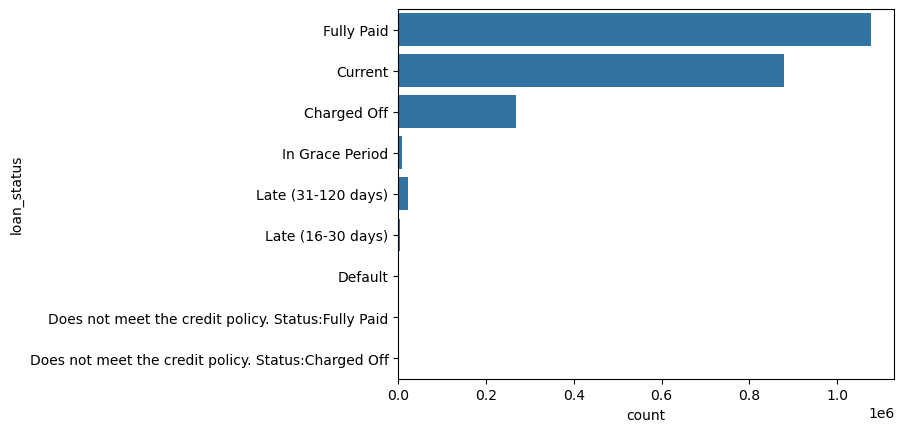

In [17]:
_ = sns.countplot(y="loan_status", data=accepted)

In [18]:
accepted = accepted[~accepted["loan_status"].isin(["Current", "In Grace Period", "Late (16-30 days)", "Does not meet the credit policy. Status:Fully Paid"])].dropna(subset=["loan_status"])
accepted["default"] = accepted["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1,
    "Late (31-120 days)": 1,
    "Default": 1,
    "Does not meet the credit policy. Status:Charged Off": 1
})

In [19]:
accepted["num_accts_ever_120_pd"].unique()

array([ 2.,  0.,  1.,  4.,  5.,  3.,  7.,  8.,  6., 17., 12., 13., 11.,
        9., 26., 10., 14., 16., 18., 25., 32., 23., 15., 20., 24., 30.,
       27., 21., 22., 19., 31., 29., 39., 28., 35., 34., 38., 33., nan,
       51.])

In [20]:
bad_closed = accepted[accepted["default"] == 1]
bad_closed["num_accts_ever_120_pd"].unique()

array([ 0.,  1.,  3.,  2.,  4.,  5., 26.,  6.,  7.,  8., 11., 10.,  9.,
       12., 15., 14., 20., 13., 21., 19., 17., 23., 18., 16., 22., 24.,
       34., 29., 30., 27., nan, 25., 32., 31., 33.])

There are defaults/charged offs with 0 accounts over 120 pd

In [21]:
accepted["delinq_2yrs"].unique()

array([ 0.,  1.,  2.,  3.,  4.,  6.,  5., 15.,  7.,  9., 10.,  8., 11.,
       13., 14., 12., 30., 18., 16., 17., 26., 20., 19., 22., 27., 39.,
       28., 25., 21., nan, 29., 24., 36.])

In [22]:
bad_closed["delinq_2yrs"].unique()

array([ 0.,  2.,  1.,  4.,  5.,  3.,  7.,  9.,  6., 11.,  8., 13., 14.,
       12., 10., 16., 18., 17., 15., 20., 19., 27., 25., 21., nan, 36.])

In [23]:
accepted["num_tl_90g_dpd_24m"].unique()

array([ 0.,  1.,  2.,  4., 12.,  7.,  3.,  8.,  5., 13., 11., 10.,  6.,
        9., 14., 30., 16., 15., 26., 22., 18., 39., 20., 17., 21., 25.,
       19., nan, 24., 36., 29.])

In [24]:
bad_closed["num_tl_90g_dpd_24m"].unique()

array([ 0.,  1.,  2.,  5.,  7.,  8., 11.,  3.,  4.,  6., 13.,  9., 10.,
       16., 12., 14., 26., 20., 15., 21., 19., 18., nan, 17., 36.])

Drop columns that would not be available for an application scorecard

In [25]:
accepted.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose',
       'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt',
       'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'recoveries',
       'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt',
       'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',
       'application_type', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op',
       'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc',

In [26]:
#columns_todrop = ["grade", "loan_status", "delinq_2yrs", "out_prncp", "out_prncp_inv", "total_pymnt", "total_pymnt_inv",
#                  "total_rec_prncp", "total_rec_int", "recoveries", "collection_recovery_fee", "last_pymnt_d", "last_pymnt_amnt",
#                  "tot_coll_amt", "tot_cur_bal", "avg_cur_bal", "bc_util", "num_accts_ever_120_pd", "num_tl_90g_dpd_24m"]

In [27]:
application_columns = ["loan_amnt", "funded_amnt", "funded_amnt_inv", "term", "int_rate", "installment", "grade",
                       "emp_length", "home_ownership", "annual_inc", "verification_status", "issue_d", "default",
                       "purpose", "addr_state", "dti", "earliest_cr_line", "fico_range_low", "fico_range_high",
                       "inq_last_6mths", "open_acc", "pub_rec", "revol_bal", "revol_util", "total_acc",
                       "initial_list_status"]
accepted = accepted[application_columns]

In [28]:
accepted.shape

(1367578, 26)

In [29]:
accepted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1367578 entries, 0 to 2260697
Data columns (total 26 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   loan_amnt            1367578 non-null  float64       
 1   funded_amnt          1367578 non-null  float64       
 2   funded_amnt_inv      1367578 non-null  float64       
 3   term                 1367578 non-null  object        
 4   int_rate             1367578 non-null  float64       
 5   installment          1367578 non-null  float64       
 6   grade                1367578 non-null  object        
 7   emp_length           1287196 non-null  object        
 8   home_ownership       1367578 non-null  object        
 9   annual_inc           1367578 non-null  float64       
 10  verification_status  1367578 non-null  object        
 11  issue_d              1367578 non-null  datetime64[ns]
 12  default              1367578 non-null  int64         
 13  pu

In [30]:
accepted.describe()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,issue_d,default,dti,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc
count,1367578.000,1367578.000,1367578.000,1367578.000,1367578.000,1367578.000,1367578,1367578.000,1367180.000,1367575,1367578.000,1367578.000,1367574.000,1367575.000,1367575.000,1367578.000,1366688.000,1367575.000
mean,14456.908,14448.475,14424.438,13.278,438.980,76256.047,2015-06-16 21:27:06.770247680,0.213,18.310,1999-03-17 05:28:23.237043584,696.116,700.116,0.657,11.593,0.216,16234.724,51.776,24.950
min,500.000,500.000,0.000,5.310,4.930,0.000,2007-06-01 00:00:00,0.000,-1.000,1934-04-01 00:00:00,615.000,619.000,0.000,0.000,0.000,0.000,0.000,1.000
25%,8000.000,8000.000,7925.000,9.750,249.050,45760.000,2014-07-01 00:00:00,0.000,11.800,1995-05-01 00:00:00,670.000,674.000,0.000,8.000,0.000,5931.000,33.400,16.000
50%,12000.000,12000.000,12000.000,12.740,375.430,65000.000,2015-08-01 00:00:00,0.000,17.630,2000-08-01 00:00:00,690.000,694.000,0.000,11.000,0.000,11122.000,52.100,23.000
75%,20000.000,20000.000,20000.000,16.020,581.618,90000.000,2016-07-01 00:00:00,0.000,24.080,2004-07-01 00:00:00,710.000,714.000,1.000,14.000,0.000,19736.000,70.700,32.000
max,40000.000,40000.000,40000.000,30.990,1719.830,10999200.000,2018-12-01 00:00:00,1.000,999.000,2015-10-01 00:00:00,845.000,850.000,33.000,90.000,86.000,2904836.000,892.300,176.000
std,8738.090,8734.279,8737.886,4.786,262.022,70309.493,NaN,0.409,11.316,NaN,31.816,31.816,0.945,5.482,0.604,22344.667,24.531,12.006


In [31]:
accepted.isna().sum()

loan_amnt                  0
funded_amnt                0
funded_amnt_inv            0
term                       0
int_rate                   0
installment                0
grade                      0
emp_length             80382
home_ownership             0
annual_inc                 0
verification_status        0
issue_d                    0
default                    0
purpose                    0
addr_state                 0
dti                      398
earliest_cr_line           3
fico_range_low             0
fico_range_high            0
inq_last_6mths             4
open_acc                   3
pub_rec                    3
revol_bal                  0
revol_util               890
total_acc                  3
initial_list_status        0
dtype: int64

Assumption about nulls:  
 - emp_length null means unemployed so 0
 - dti null means no debt so 0
 - revol_util null means no utilization so 0
 - inq_last_6mths null means no inquiries so 0
 - open_acc null means no open accounts so 0
 - pub_rec null means no records, so 0
 - total_acc null means no accounts, so 0

In [32]:
accepted.loc[:,"emp_length"] = accepted["emp_length"].fillna("0")
accepted.loc[:,"dti"] = accepted["dti"].fillna(0)
accepted.loc[:,"revol_util"] = accepted["revol_util"].fillna(0)
accepted.loc[:, "inq_last_6mths"] = accepted["inq_last_6mths"].fillna(0)
accepted.loc[:, "open_acc"] = accepted["open_acc"].fillna(0)
accepted.loc[:, "pub_rec"] = accepted["pub_rec"].fillna(0)
accepted.loc[:, "total_acc"] = accepted["total_acc"].fillna(0)

In [33]:
stats.kstests(accepted, "default")

,feature,statistic,pvalue
0,loan_amnt,0.084,0.000
1,funded_amnt,0.084,0.000
2,funded_amnt_inv,0.084,0.000
3,int_rate,0.265,0.000
4,installment,0.073,0.000
5,annual_inc,0.068,0.000
6,dti,0.111,0.000
7,fico_range_low,0.134,0.000
8,fico_range_high,0.134,0.000
9,inq_last_6mths,0.070,0.000


In [34]:
stats.pearson_chi2(accepted, "default")

,feature,statistic,pvalue
0,term,44727.489,0.000
1,grade,95209.381,0.000
2,emp_length,3139.242,0.000
3,home_ownership,7009.114,0.000
4,verification_status,10967.742,0.000
5,purpose,4351.962,0.000
6,addr_state,NaN,NaN
7,initial_list_status,451.394,0.000


<Axes: >

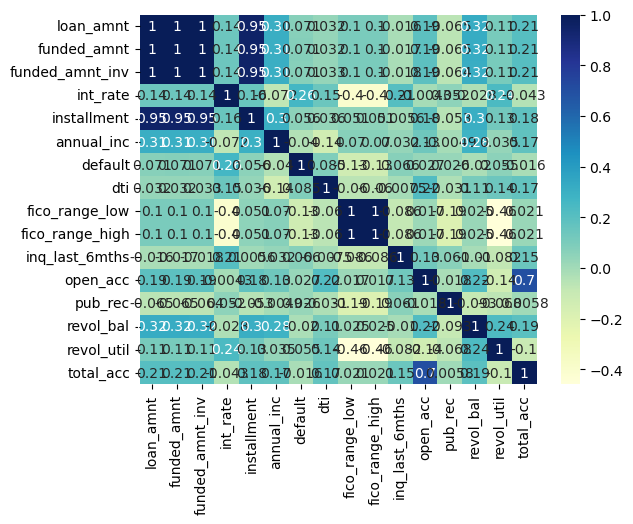

In [35]:
viz.correlation_heatmap(accepted)

Default

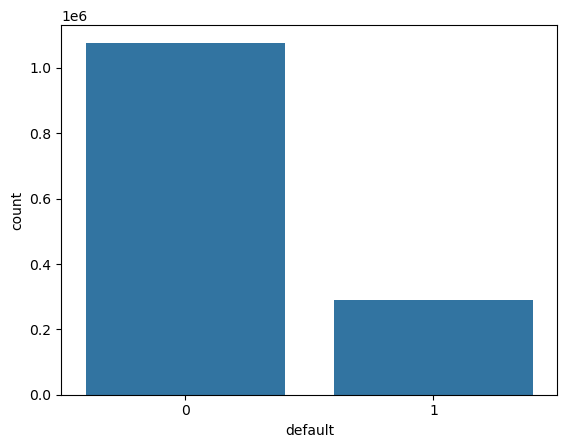

In [36]:
_ = sns.countplot(data=accepted, x="default")

In [37]:
accepted["default"].mean()

np.float64(0.2126584370324764)

loan_amnt

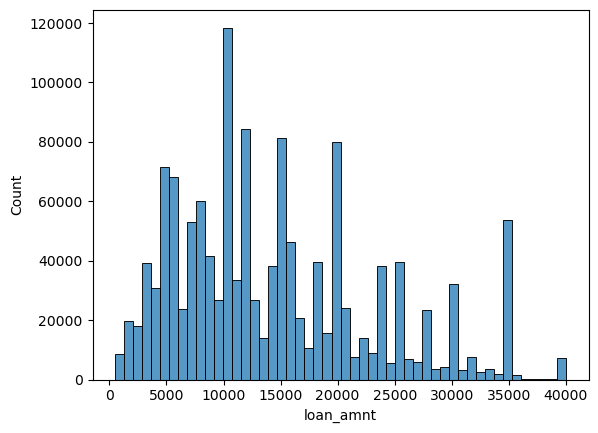

In [38]:
_ = sns.histplot(accepted["loan_amnt"], bins=50)

In [39]:
stats.kstests(accepted, "default", selected_columns=["loan_amnt"])

,feature,statistic,pvalue
0,loan_amnt,0.084,0.000


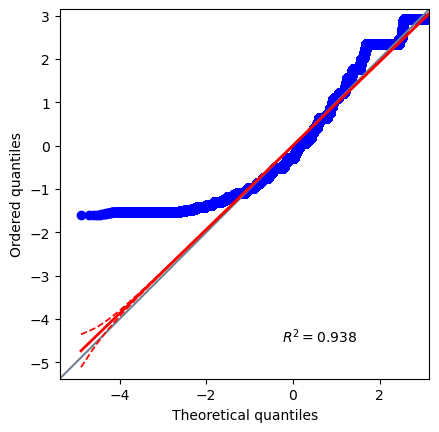

In [40]:
_ = pg.qqplot(accepted["loan_amnt"], dist='norm')

right skewed

funded_amnt

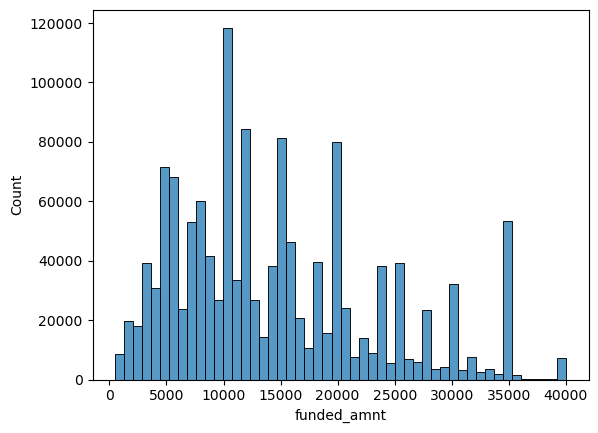

In [41]:
_ = sns.histplot(accepted["funded_amnt"], bins=50)

In [42]:
stats.kstests(accepted, "default", selected_columns=["funded_amnt"])

,feature,statistic,pvalue
0,funded_amnt,0.084,0.000


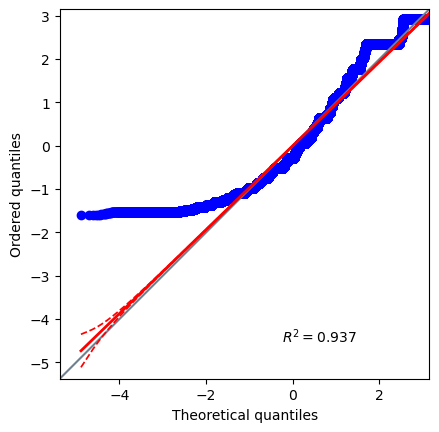

In [43]:
_ = pg.qqplot(accepted["funded_amnt"], dist='norm')

funded_amnt_inv

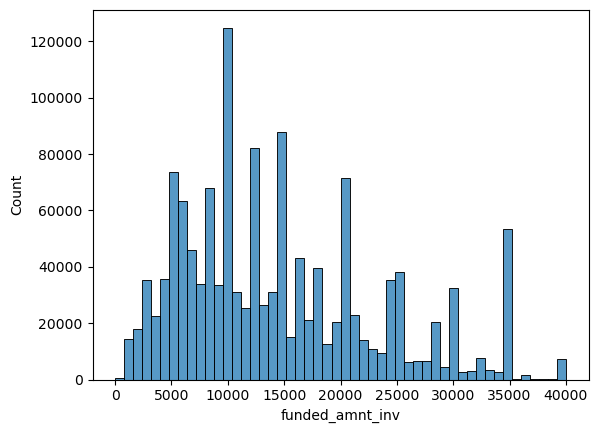

In [44]:
_ = sns.histplot(accepted["funded_amnt_inv"], bins=50)

In [45]:
stats.kstests(accepted, "default", selected_columns=["funded_amnt_inv"])

,feature,statistic,pvalue
0,funded_amnt_inv,0.084,0.000


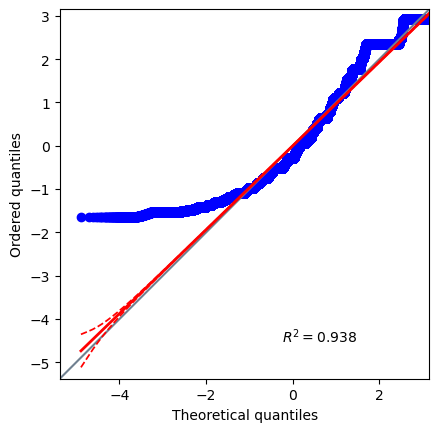

In [46]:
_ = pg.qqplot(accepted["funded_amnt_inv"], dist='norm')

term

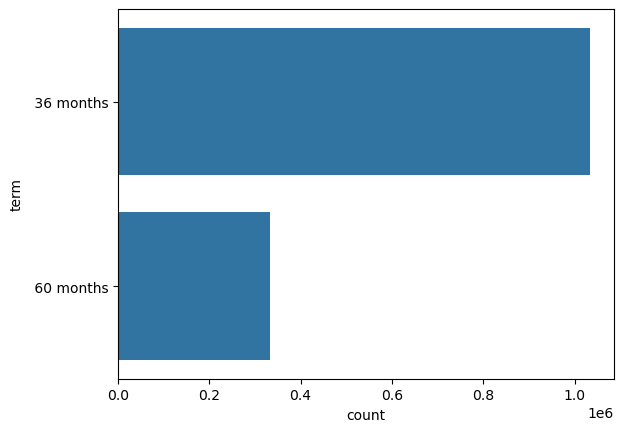

In [47]:
_ = sns.countplot(accepted["term"])

In [48]:
pd.crosstab(accepted["term"], accepted["default"])

default,0,1
term,,
36 months,857491,176400
60 months,219260,114427


In [49]:
pd.crosstab(accepted["term"], accepted["default"], normalize="all")

default,0,1
term,,
36 months,0.627,0.129
60 months,0.160,0.084


In [50]:
pd.crosstab(accepted["term"], accepted["default"], normalize="index")

default,0,1
term,,
36 months,0.829,0.171
60 months,0.657,0.343


In [51]:
stats.pearson_chi2(accepted, "default", selected_columns=["term"])

,feature,statistic,pvalue
0,term,44727.489,0.000


int_rate

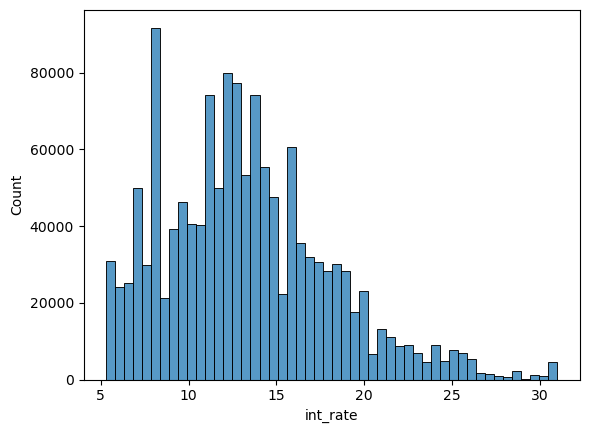

In [52]:
_ = sns.histplot(accepted["int_rate"], bins=50)

In [53]:
stats.kstests(accepted, "default", selected_columns=["int_rate"])

,feature,statistic,pvalue
0,int_rate,0.265,0.000


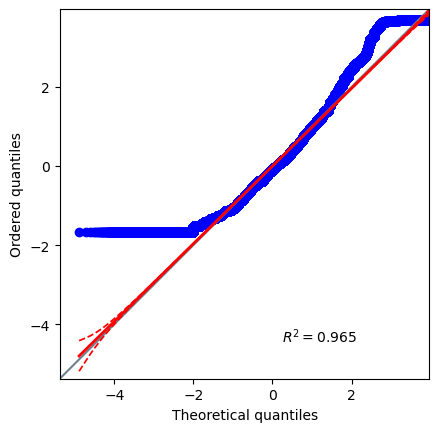

In [54]:
_ = pg.qqplot(accepted["int_rate"], dist='norm')

installment

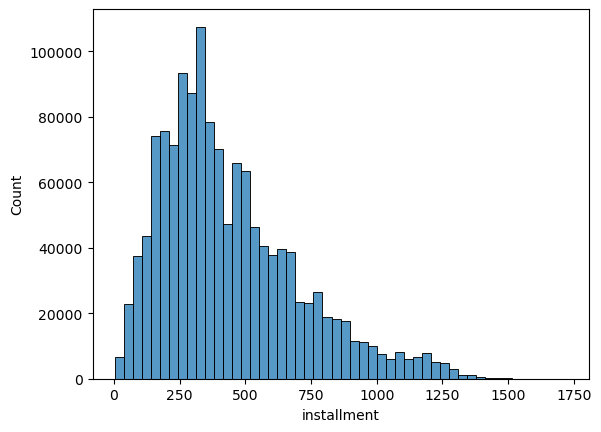

In [55]:
_ = sns.histplot(accepted["installment"], bins=50)

In [56]:
stats.kstests(accepted, "default", selected_columns=["installment"])

,feature,statistic,pvalue
0,installment,0.073,0.000


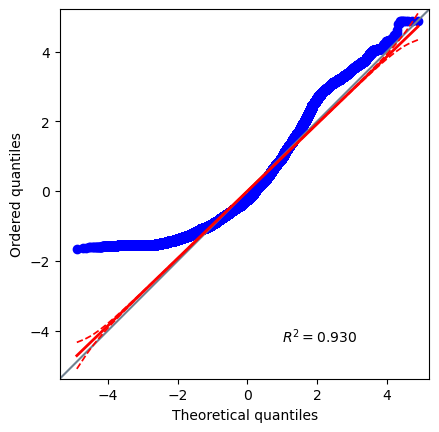

In [57]:
_ = pg.qqplot(accepted["installment"], dist='norm')

grade

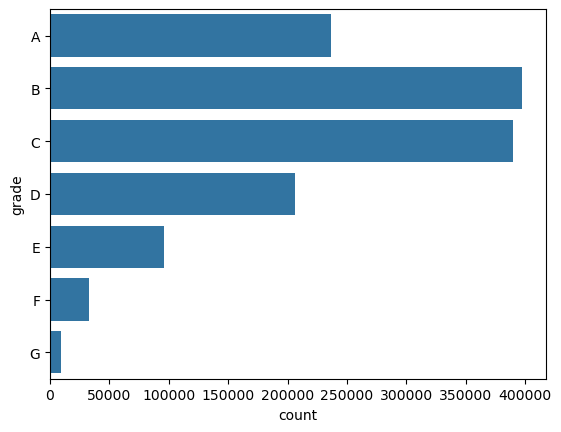

In [58]:
_ = sns.countplot(accepted["grade"], order=sorted(accepted["grade"].unique()))

In [59]:
pd.crosstab(accepted["grade"], accepted["default"])

default,0,1
grade,,
A,220889,15536
B,340172,57449
C,296037,93359
D,139899,66025
E,57615,38365
F,17567,15225
G,4572,4868


In [60]:
pd.crosstab(accepted["grade"], accepted["default"], normalize="all")

default,0,1
grade,,
A,0.162,0.011
B,0.249,0.042
C,0.216,0.068
D,0.102,0.048
E,0.042,0.028
F,0.013,0.011
G,0.003,0.004


In [61]:
pd.crosstab(accepted["grade"], accepted["default"], normalize="index")

default,0,1
grade,,
A,0.934,0.066
B,0.856,0.144
C,0.760,0.240
D,0.679,0.321
E,0.600,0.400
F,0.536,0.464
G,0.484,0.516


In [62]:
pd.crosstab(accepted["grade"], accepted["default"], normalize="columns")

default,0,1
grade,,
A,0.205,0.053
B,0.316,0.198
C,0.275,0.321
D,0.130,0.227
E,0.054,0.132
F,0.016,0.052
G,0.004,0.017


In [63]:
stats.pearson_chi2(accepted, "default", selected_columns=["grade"])

,feature,statistic,pvalue
0,grade,95209.381,0.000


Will need to remove this column, since the goal an application scorecard is to make its own grade

emp_length

In [64]:
accepted["emp_length"].head()

0    10+ years
1    10+ years
2    10+ years
4      3 years
5      4 years
Name: emp_length, dtype: object

In [65]:
accepted["emp_length"].unique()

array(['10+ years', '3 years', '4 years', '6 years', '7 years', '8 years',
       '2 years', '5 years', '9 years', '< 1 year', '1 year', '0'],
      dtype=object)

In [66]:
accepted["employment_length"] = accepted["emp_length"].str.replace("+ years", "")
accepted["employment_length"] = accepted["employment_length"].str.replace(" years", "")
accepted["employment_length"] = accepted["employment_length"].str.replace(" year", "")
accepted["employment_length"] = accepted["employment_length"].str.replace("< 1", "0")
accepted["employment_length"] = accepted["employment_length"].astype(int)
accepted["employment_length"].head()

0    10
1    10
2    10
4     3
5     4
Name: employment_length, dtype: int64

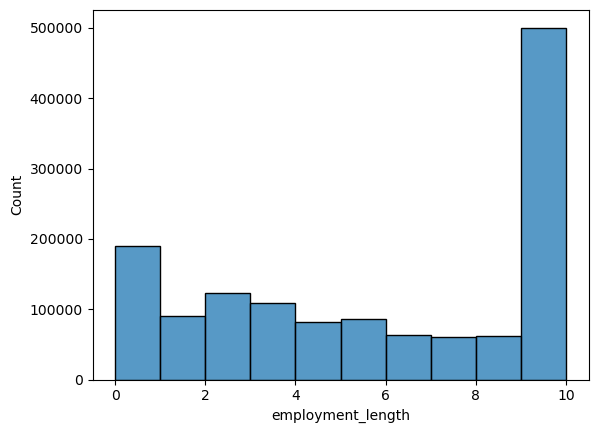

In [67]:
_ = sns.histplot(accepted["employment_length"], bins=10)

In [68]:
stats.kstests(accepted, "default", selected_columns=["employment_length"])

,feature,statistic,pvalue
0,employment_length,0.032,0.000


In [69]:
stats.pearson_chi2(accepted, "default", selected_columns=["emp_length"])

,feature,statistic,pvalue
0,emp_length,3139.242,0.000


In [70]:
pd.crosstab(accepted["emp_length"], accepted["default"])

default,0,1
emp_length,,
0,57381,23001
1 year,70296,19732
10+ years,359142,89796
2 years,97629,26168
3 years,86111,23357
4 years,64656,17371
5 years,67659,17864
6 years,50593,13104
7 years,48004,12423


In [71]:
pd.crosstab(accepted["emp_length"], accepted["default"], normalize="all")

default,0,1
emp_length,,
0,0.042,0.017
1 year,0.051,0.014
10+ years,0.263,0.066
2 years,0.071,0.019
3 years,0.063,0.017
4 years,0.047,0.013
5 years,0.049,0.013
6 years,0.037,0.010
7 years,0.035,0.009


In [72]:
pd.crosstab(accepted["emp_length"], accepted["default"], normalize="index")

default,0,1
emp_length,,
0,0.714,0.286
1 year,0.781,0.219
10+ years,0.800,0.200
2 years,0.789,0.211
3 years,0.787,0.213
4 years,0.788,0.212
5 years,0.791,0.209
6 years,0.794,0.206
7 years,0.794,0.206


home_ownership

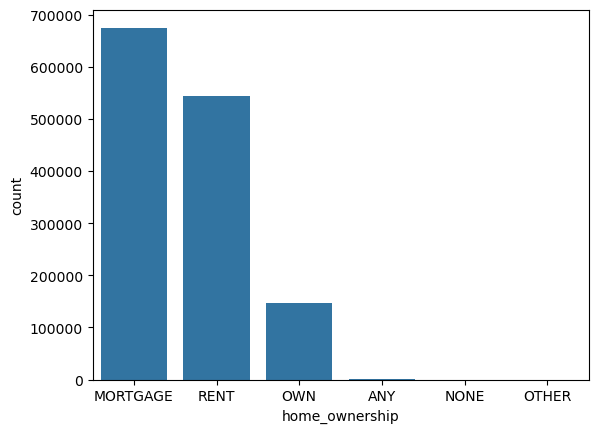

In [73]:
_ = sns.countplot(data=accepted, x="home_ownership")

In [74]:
pd.crosstab(accepted["home_ownership"], accepted["default"])

default,0,1
home_ownership,,
ANY,230,74
MORTGAGE,551048,124204
NONE,41,8
OTHER,117,38
OWN,114968,32607
RENT,410347,133896


In [75]:
pd.crosstab(accepted["home_ownership"], accepted["default"], normalize="all")

default,0,1
home_ownership,,
ANY,0.000,0.000
MORTGAGE,0.403,0.091
NONE,0.000,0.000
OTHER,0.000,0.000
OWN,0.084,0.024
RENT,0.300,0.098


In [76]:
pd.crosstab(accepted["home_ownership"], accepted["default"], normalize="index")

default,0,1
home_ownership,,
ANY,0.757,0.243
MORTGAGE,0.816,0.184
NONE,0.837,0.163
OTHER,0.755,0.245
OWN,0.779,0.221
RENT,0.754,0.246


In [77]:
stats.pearson_chi2(accepted, "default", selected_columns=["home_ownership"])

,feature,statistic,pvalue
0,home_ownership,7009.114,0.000


annual_inc 

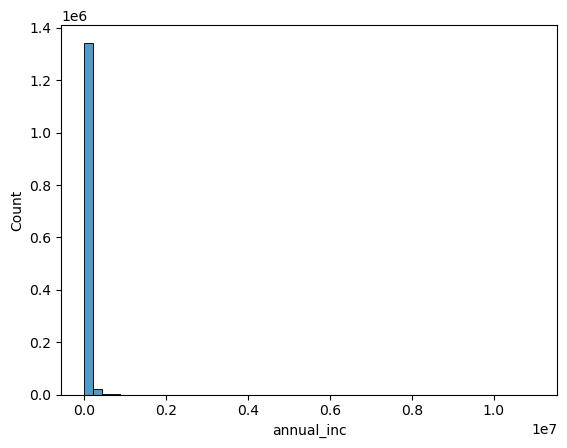

In [78]:
_ = sns.histplot(accepted["annual_inc"], bins=50)

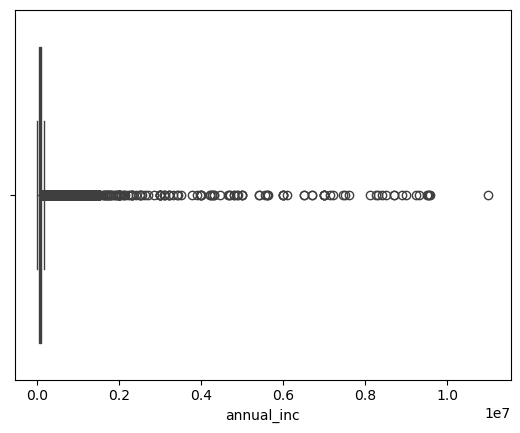

In [79]:
_ = sns.boxplot(data=accepted, x="annual_inc")

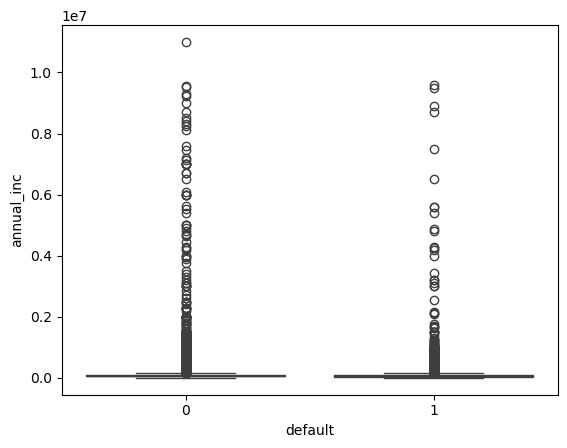

In [80]:
_ = sns.boxplot(data=accepted, x="default", y="annual_inc")

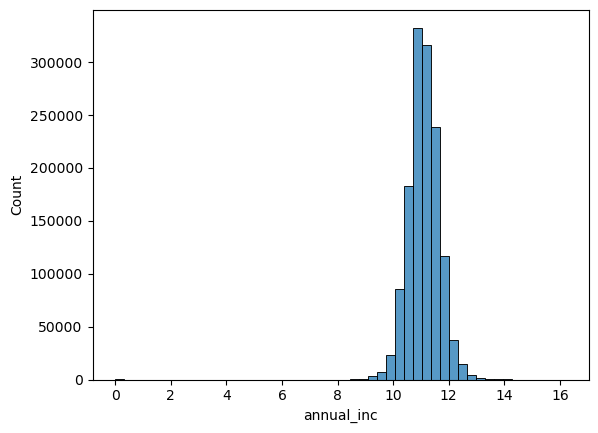

In [81]:
logged_income = np.log(accepted["annual_inc"] + 1)
_ = sns.histplot(logged_income, bins=50)

The zeros might be skewing

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

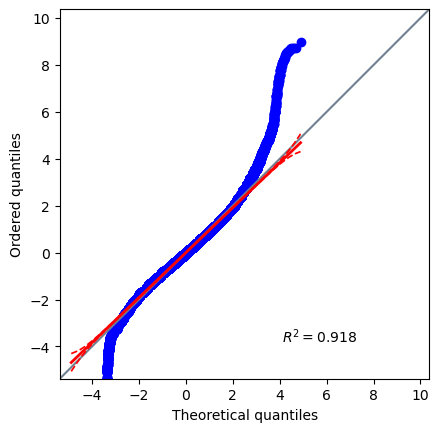

In [82]:
_ = pg.qqplot(logged_income, dist='norm')

In [84]:
accepted['logged_income'] = logged_income
stats.kstests(accepted, "default", selected_columns=["logged_income", "annual_inc"])

,feature,statistic,pvalue
0,logged_income,0.068,0.000
1,annual_inc,0.068,0.000


verification_status

In [85]:
accepted["verification_status"].unique()

array(['Not Verified', 'Source Verified', 'Verified'], dtype=object)

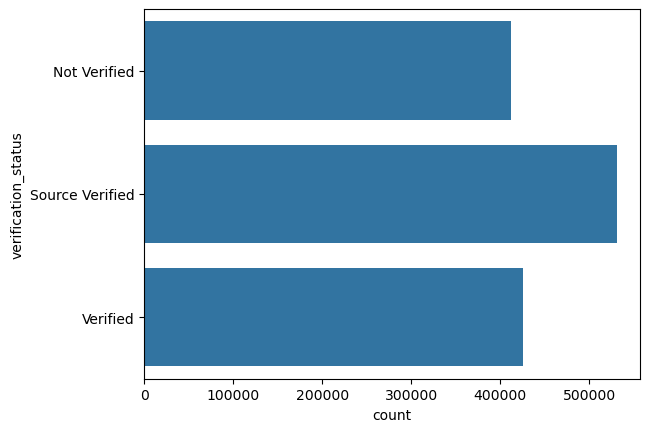

In [86]:
_ = sns.countplot(accepted["verification_status"])

In [87]:
pd.crosstab(accepted["verification_status"], accepted["default"])

default,0,1
verification_status,,
Not Verified,346166,65773
Source Verified,412041,118379
Verified,318544,106675


In [89]:
pd.crosstab(accepted["verification_status"], accepted["default"], normalize='all')

default,0,1
verification_status,,
Not Verified,0.253,0.048
Source Verified,0.301,0.087
Verified,0.233,0.078


In [90]:
pd.crosstab(accepted["verification_status"], accepted["default"], normalize='index')

default,0,1
verification_status,,
Not Verified,0.840,0.160
Source Verified,0.777,0.223
Verified,0.749,0.251


Income verification indicates higher default rate??

In [93]:
pd.crosstab(accepted["verification_status"], accepted["default"], normalize='columns')

default,0,1
verification_status,,
Not Verified,0.321,0.226
Source Verified,0.383,0.407
Verified,0.296,0.367


In [91]:
stats.pearson_chi2(accepted, "default", selected_columns=["verification_status"])

,feature,statistic,pvalue
0,verification_status,10967.742,0.000


issue_d

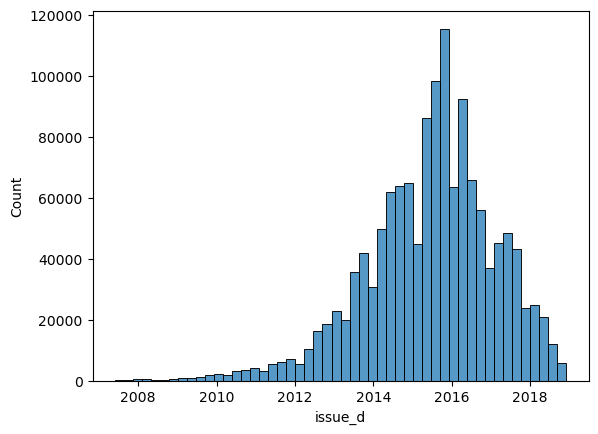

In [95]:
_ = sns.histplot(accepted["issue_d"], bins=50)

Purpose

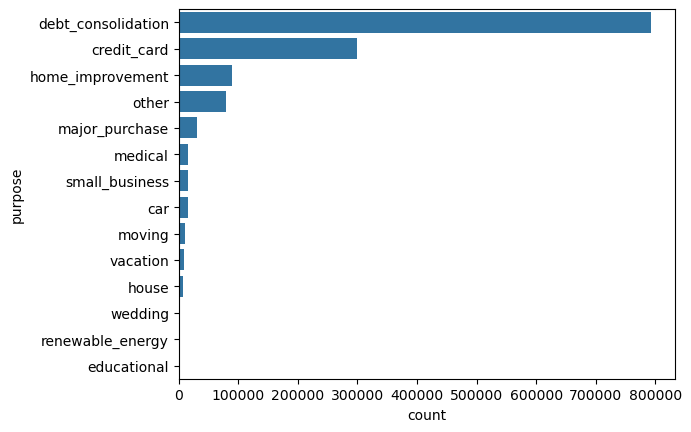

In [97]:
_ = sns.countplot(accepted["purpose"], order=accepted["purpose"].value_counts().index)

In [98]:
pd.crosstab(accepted["purpose"], accepted["default"])

default,0,1
purpose,,
car,12444,2349
credit_card,245297,54071
debt_consolidation,615307,177802
educational,270,88
home_improvement,72002,17017
house,5666,1786
major_purchase,23952,6066
medical,12167,3705
moving,7266,2407


This would definitely benefit from WoE encoding

In [102]:
optb = OptimalBinning(name="purpose", dtype="categorical", solver="cp")

In [103]:
optb.fit(x=accepted["purpose"], y=accepted["default"])

OptimalBinning(dtype='categorical', name='purpose')

In [104]:
optb.status

'OPTIMAL'

In [105]:
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"[wedding, car, credit_card]",316468,0.231,259756,56712,0.179,0.213,0.010,0.001
1,"[home_improvement, major_purchase]",119037,0.087,95954,23083,0.194,0.116,0.001,0.000
2,"[vacation, debt_consolidation]",802341,0.587,622634,179707,0.224,-0.066,0.003,0.000
3,"[other, medical, house, educational, moving, r...",129732,0.095,98407,31325,0.241,-0.164,0.003,0.000
4,Special,0,0.000,0,0,0.000,0.000,0.000,0.000
5,Missing,0,0.000,0,0,0.000,0.000,0.000,0.000
Totals,,1367578,1.000,1076751,290827,0.213,,0.016,0.002


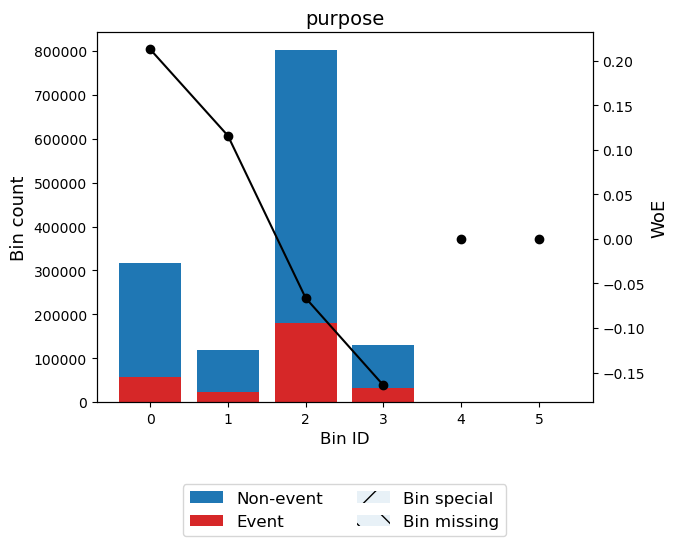

In [106]:
optb.binning_table.plot(metric="woe")

IV is very low, might not be useful for prediction